In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("Final_Marks_Data.csv")
df.head()

,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66


In [9]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Student_ID                     2000 non-null   object
 1   Attendance (%)                 2000 non-null   int64 
 2   Internal Test 1 (out of 40)    2000 non-null   int64 
 3   Internal Test 2 (out of 40)    2000 non-null   int64 
 4   Assignment Score (out of 10)   2000 non-null   int64 
 5   Daily Study Hours              2000 non-null   int64 
 6   Final Exam Marks (out of 100)  2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,84.891500,32.115500,32.464500,7.507000,2.823500,64.855000
std,7.758855,4.563504,4.522827,1.021015,0.608714,11.341265
min,52.000000,18.000000,16.000000,4.000000,1.000000,25.000000
25%,80.000000,29.000000,29.000000,7.000000,2.000000,58.000000
50%,85.000000,32.000000,33.000000,8.000000,3.000000,65.000000
75%,90.000000,35.000000,36.000000,8.000000,3.000000,73.000000
max,100.000000,40.000000,40.000000,10.000000,5.000000,100.000000


In [11]:
df.isnull().sum()

Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64

In [13]:
df['Final Exam Marks (out of 100)'].mean()

np.float64(64.855)

In [20]:
df['Final Exam Marks (out of 100)'].max()

100

In [22]:
df['Final Exam Marks (out of 100)'].min()

25

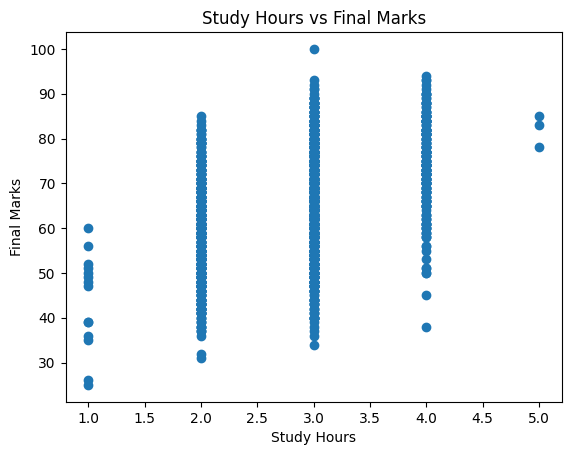

In [24]:
plt.scatter(df['Daily Study Hours'], df['Final Exam Marks (out of 100)'])
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")
plt.show()

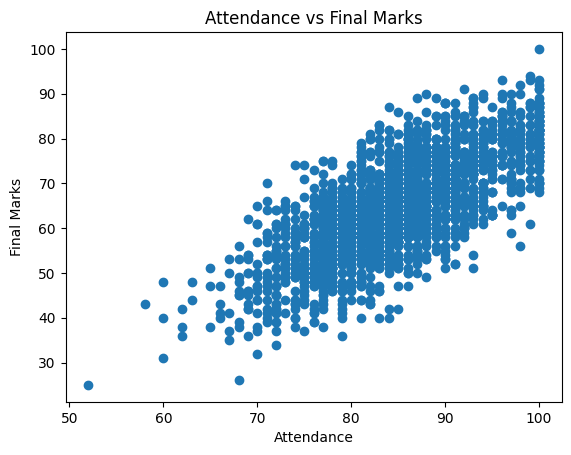

In [26]:
plt.scatter(df['Attendance (%)'], df['Final Exam Marks (out of 100)'])
plt.xlabel("Attendance")
plt.ylabel("Final Marks")
plt.title("Attendance vs Final Marks")
plt.show()

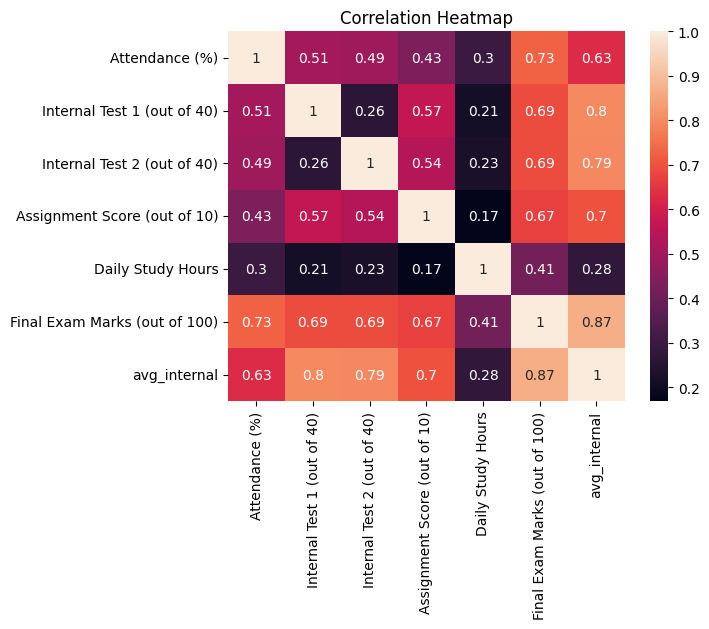

In [49]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [50]:
df.columns

Index(['Student_ID', 'Attendance (%)', 'Internal Test 1 (out of 40)',
       'Internal Test 2 (out of 40)', 'Assignment Score (out of 10)',
       'Daily Study Hours', 'Final Exam Marks (out of 100)', 'avg_internal'],
      dtype='object')

In [52]:
df['avg_internal'] = (
    pd.to_numeric(df['Internal Test 1 (out of 40)'], errors='coerce') +
    pd.to_numeric(df['Internal Test 2 (out of 40)'], errors='coerce')
) / 2

In [53]:
df[['Internal Test 1 (out of 40)', 'Internal Test 2 (out of 40)', 'avg_internal']].head()

,Internal Test 1 (out of 40),Internal Test 2 (out of 40),avg_internal
0,30,36,33.0
1,24,38,31.0
2,29,26,27.5
3,36,35,35.5
4,31,37,34.0


In [55]:
def performance(score):
    if score >= 75:
        return "Good"
    elif score >= 50:
        return "Average"
    else:
        return "Poor"

df['Performance'] = df['Final Exam Marks (out of 100)'].apply(performance)

df[['Final Exam Marks (out of 100)', 'Performance']].head(10)

,Final Exam Marks (out of 100),Performance
0,72,Average
1,56,Average
2,56,Average
3,74,Average
4,66,Average
5,79,Good
6,83,Good
7,77,Good
8,71,Average
9,61,Average


In [56]:
df['Performance'].value_counts()

Performance
Average    1387
Good        425
Poor        188
Name: count, dtype: int64

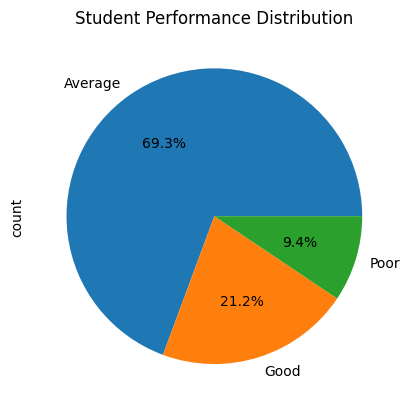

In [57]:
df['Performance'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Student Performance Distribution")
plt.show()

Students who study more than 3 hours score higher
Attendance above 80% improves performance
Internal tests strongly affect final marks
Assignment scores have moderate impact

In [58]:
import os
os.getcwd()

'C:\\Users\\ASUS'